# Module 1c - Dataset Gallery: one pipeline, five domains

Module 1a built a composition-to-property pipeline on OER electrocatalysts: map each element to physical properties, climb a model ladder from linear to committee, then read the result with SHAP. This notebook runs that same pipeline across five small datasets from different fields, so you can point it at the domain closest to your own research and see how the pipeline behaves there.

Everything 1a teaches still holds, so we do not re-explain it. The point here is coverage: pick a dataset, run, compare. All five load through `matminer`, which needs no API key.

| `DATASET` | domain | rows | target (unit) |
|---|---|---|---|
| `matbench_steels` | alloys / mechanical | 312 | yield strength (MPa) |
| `m2ax` | MAX-phase ceramics | 223 | bulk modulus (GPa) |
| `double_perovskites_gap` | photovoltaics | 1306 | band gap (eV) |
| `heusler_magnetic` | magnetics / spintronics | 1153 | magnetic moment (mu_B) |
| `expt_formation_enthalpy` | thermodynamics | 1196 | formation enthalpy (eV/atom) |

Row counts are the usable rows after dropping records with a missing composition or target. One line, `DATASET = "..."`, selects the domain that gets the close-up look (features, parity plot, SHAP, classification); the gallery table always covers all five.

## 0. Setup

In [ ]:
# Colab setup: fetch the data and enter this module's folder. No-op when run locally.
import os, sys
REPO = "https://github.com/ruiding-uchicago/NRT_Training_Materials.git"
MODULE = "module_1_tabular_ML"
if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != MODULE:
    root = "/content/NRT_Training_Materials"
    if not os.path.isdir(root):
        os.system("git clone --depth 1 " + REPO + " " + root)
    os.chdir(root + "/" + MODULE)
print("ready in", os.getcwd())

In [2]:
import sys, subprocess
# matminer + pymatgen supply the datasets and the element-property featurizer;
# shap and xgboost are the same tools as 1a. Colab ships none of these, so install on Colab (no-op locally).
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matminer", "pymatgen", "xgboost", "shap"])

In [3]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pymatgen.core import Composition
from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
RND = 42
os.makedirs("figures", exist_ok=True)
os.makedirs("data/gallery", exist_ok=True)

## 1. The config: one dictionary, one selector

Each dataset is one entry: its matminer loader name, the composition or formula column, the numeric target, and a unit for labels. To run your own domain, change the single `DATASET` line below to any key in `DATASETS`.

In [4]:
DATASETS = {
    "matbench_steels":         dict(comp="composition", target="yield strength", unit="MPa",     label="steel yield strength"),
    "m2ax":                    dict(comp="formula",     target="bulk modulus",   unit="GPa",     label="MAX-phase bulk modulus"),
    "double_perovskites_gap":  dict(comp="formula",     target="gap gllbsc",     unit="eV",      label="double-perovskite band gap"),
    "heusler_magnetic":        dict(comp="formula",     target="mu_b",           unit="mu_B",    label="Heusler magnetic moment"),
    "expt_formation_enthalpy": dict(comp="formula",     target="e_form expt",    unit="eV/atom", label="formation enthalpy"),
}

# >>> Change this one line to your domain, then Run All. <<<
DATASET = "matbench_steels"

assert DATASET in DATASETS
print("close-up dataset:", DATASET, "->", DATASETS[DATASET]["label"])

close-up dataset: matbench_steels -> steel yield strength


## 2. Load and cache

`load_one` reads a small cached CSV of just `(composition, target)` if present, and otherwise fetches through matminer and writes that cache. After the first run the notebook is offline and fast. This is the same idea as 1a's local CSV, one file per dataset under `data/gallery/`.

In [5]:
def load_one(name):
    """Return a DataFrame with columns [composition, target], cached under data/gallery/."""
    cfg = DATASETS[name]
    cache = f"data/gallery/{name}.csv"
    if os.path.exists(cache):
        d = pd.read_csv(cache)
    else:
        raw = load_dataset(name)[[cfg["comp"], cfg["target"]]].dropna().reset_index(drop=True)
        d = raw.rename(columns={cfg["comp"]: "composition", cfg["target"]: "target"})
        d.to_csv(cache, index=False)
    return d

d = load_one(DATASET)
print(f"{DATASET}: {len(d)} rows   target = {DATASETS[DATASET]['target']} ({DATASETS[DATASET]['unit']})")
d.head(3)

matbench_steels: 312 rows   target = yield strength (MPa)


,composition,target
0,Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...,2411.5
1,Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....,1123.1
2,Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....,1736.3


## 3. Featurize from composition

1a hand-built a small element-to-property table. Here we use matminer's `ElementProperty` "magpie" preset, which does the same thing at larger scale: for each composition it turns the elements into 132 statistics (mean, spread, range, and mode of tabulated atomic properties such as atomic number, electronegativity, and number of valence electrons). Same idea as 1a, chemistry-aware features rather than one-hot, applied to whatever elements a dataset contains.

In [6]:
EP = ElementProperty.from_preset("magpie")
EP.set_n_jobs(1)   # single process keeps behavior identical on Colab and locally

def featurize(d):
    comps = [Composition(s) for s in d["composition"]]
    X = pd.DataFrame(EP.featurize_many(comps, ignore_errors=True, pbar=False),
                     columns=EP.feature_labels())
    y = d["target"].astype(float)
    keep = X.notna().all(axis=1)          # drop any composition the featurizer could not parse
    return X[keep].reset_index(drop=True), y[keep].reset_index(drop=True)

X, y = featurize(d)
print("feature matrix:", X.shape, "  (132 magpie features)")
X.iloc[:3, :5]

feature matrix: (312, 132)   (132 magpie features)


,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number
0,6.0,42.0,36.0,26.664769,1.152116
1,6.0,74.0,68.0,26.300744,1.522817
2,13.0,42.0,29.0,26.145400,0.858372


## 4. The model ladder (same as 1a)

Linear, decision tree, random forest, XGBoost, MLP, then a committee that averages the last three and reports their spread as an uncertainty signal. The code is 1a's; only the data changed. We print the compact scoreboard for the close-up dataset.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

def build_models():
    return {
        "Linear":       LinearRegression(),
        "DecisionTree": DecisionTreeRegressor(max_depth=8, random_state=RND),
        "RandomForest": RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RND),
        "XGBoost":      XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                                     subsample=0.8, colsample_bytree=0.8, random_state=RND, n_jobs=-1),
        "MLP":          make_pipeline(StandardScaler(),
                            MLPRegressor(hidden_layer_sizes=(256, 128), alpha=3e-4,
                                         learning_rate_init=8e-4, max_iter=1500, early_stopping=True,
                                         n_iter_no_change=30, random_state=RND)),
    }

def run_ladder(X, y, seed=RND):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.1, random_state=seed)
    res = {}
    for name, m in build_models().items():
        m.fit(Xtr, ytr); p = m.predict(Xte)
        res[name] = dict(model=m, pred=p, R2=r2_score(yte, p), MAE=mean_absolute_error(yte, p))
    P = np.column_stack([res[k]["pred"] for k in ["RandomForest", "XGBoost", "MLP"]])
    ens, std = P.mean(1), P.std(1)
    res["Committee"] = dict(model=None, pred=ens, R2=r2_score(yte, ens),
                            MAE=mean_absolute_error(yte, ens), std=std)
    return dict(res=res, split=(Xtr, Xte, ytr, yte))

fit = run_ladder(X, y)
u = DATASETS[DATASET]["unit"]
for name, r in fit["res"].items():
    print(f"{name:14s}  R2={r['R2']:6.3f}   MAE={r['MAE']:8.4g} {u}")

Linear          R2= 0.540   MAE=   143.7 MPa
DecisionTree    R2= 0.413   MAE=   140.2 MPa
RandomForest    R2= 0.836   MAE=   73.33 MPa
XGBoost         R2= 0.875   MAE=   68.25 MPa
MLP             R2= 0.707   MAE=     114 MPa
Committee       R2= 0.848   MAE=   80.03 MPa


## 5. The gallery: best model on every dataset

The same ladder on all five domains, reduced to one row each: the best model, its test R2, and MAE in the target's own unit. Read down the R2 column and the pattern from 1a repeats. Tree ensembles (or, on the largest set, the MLP) lead, and the linear baseline trails. The one low score, Heusler magnetic moment, is an honest result: magnetism depends on structure and spin state, which composition-only features cannot fully capture. Knowing where the pipeline is weak matters as much as knowing where it is strong.

In [8]:
rows = []
for name in DATASETS:
    Xi, yi = featurize(load_one(name))
    r = run_ladder(Xi, yi)["res"]
    reg = {k: v for k, v in r.items() if k != "Committee"}
    best = max(reg, key=lambda k: reg[k]["R2"])
    rows.append(dict(dataset=name, domain=DATASETS[name]["label"], n=len(yi),
                     best_model=best, test_R2=round(r[best]["R2"], 3),
                     test_MAE=round(r[best]["MAE"], 4), unit=DATASETS[name]["unit"]))
gallery = pd.DataFrame(rows)
gallery

,dataset,domain,n,best_model,test_R2,test_MAE,unit
0,matbench_steels,steel yield strength,312,XGBoost,0.875,68.2539,MPa
1,m2ax,MAX-phase bulk modulus,223,XGBoost,0.922,8.0816,GPa
2,double_perovskites_gap,double-perovskite band gap,1306,MLP,0.964,0.2193,eV
3,heusler_magnetic,Heusler magnetic moment,1153,Linear,0.551,0.8271,mu_B
4,expt_formation_enthalpy,formation enthalpy,1196,XGBoost,0.869,0.0589,eV/atom


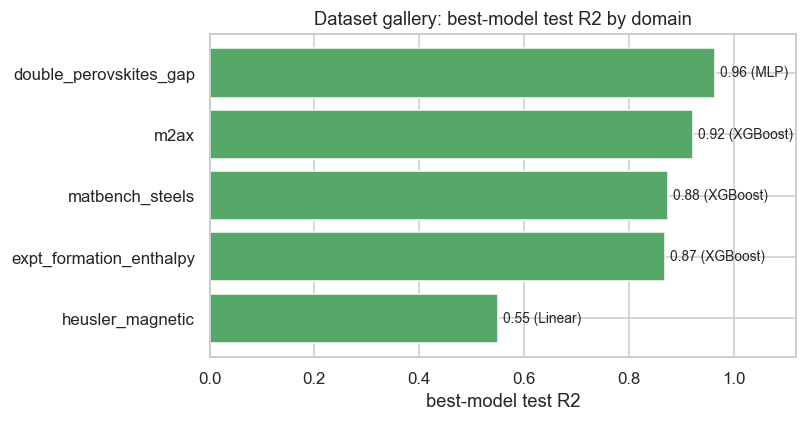

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4))
g = gallery.sort_values("test_R2")
ax.barh(g["dataset"], g["test_R2"], color="#55A868")
for yv, (r2, m) in enumerate(zip(g["test_R2"], g["best_model"])):
    ax.text(r2 + 0.01, yv, f"{r2:.2f} ({m})", va="center", fontsize=9)
ax.set(xlim=(0, 1.12), xlabel="best-model test R2", title="Dataset gallery: best-model test R2 by domain")
fig.tight_layout(); fig.savefig("figures/1c_gallery_r2.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Close-up on one dataset: parity and SHAP

The table compresses each domain to a number. Here is the fuller picture for the dataset in `DATASET`: a parity plot of the strong tree model, and a SHAP beeswarm of which features drive its prediction. We use XGBoost for the close-up because it gives a clean tree explainer and sits at or near the top on every dataset here. Change `DATASET` at the top and this whole section re-renders for your domain.

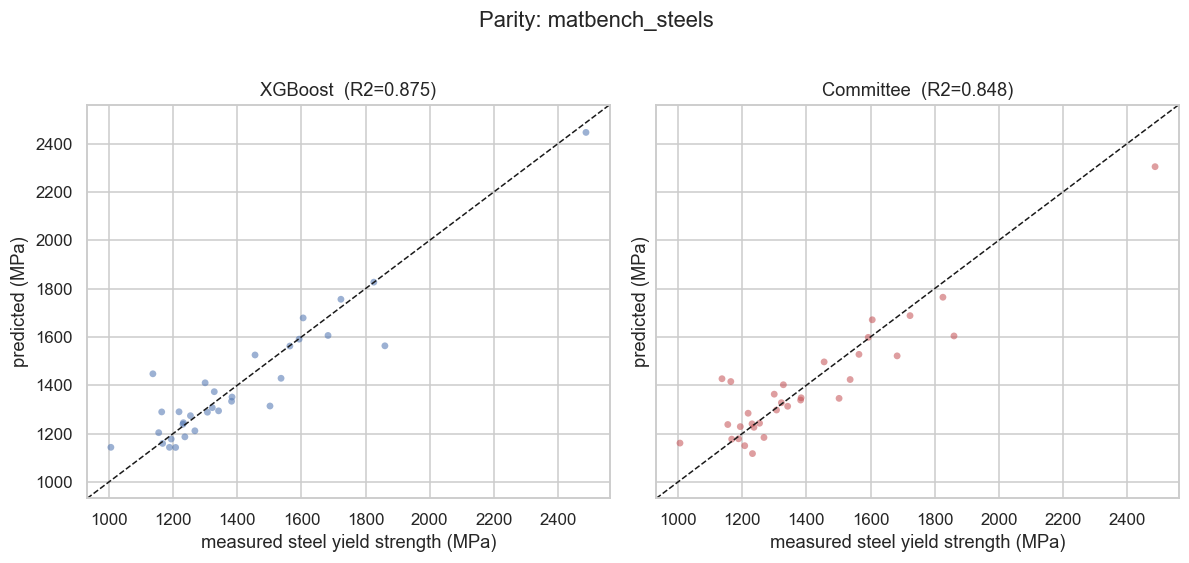

In [10]:
res = fit["res"]
Xtr, Xte, ytr, yte = fit["split"]
xgb = res["XGBoost"]["model"]
lims = [min(yte.min(), res["XGBoost"]["pred"].min()), max(yte.max(), res["XGBoost"]["pred"].max())]
pad = 0.05 * (lims[1] - lims[0]); lims = [lims[0] - pad, lims[1] + pad]

fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for a, key, col in [(ax[0], "XGBoost", "#4C72B0"), (ax[1], "Committee", "#C44E52")]:
    a.scatter(yte, res[key]["pred"], s=20, alpha=0.55, color=col, edgecolor="none")
    a.plot(lims, lims, "k--", lw=1)
    a.set(xlim=lims, ylim=lims, title=f"{key}  (R2={res[key]['R2']:.3f})",
          xlabel=f"measured {DATASETS[DATASET]['label']} ({u})",
          ylabel=f"predicted ({u})")
fig.suptitle(f"Parity: {DATASET}", y=1.02)
fig.tight_layout(); fig.savefig("figures/1c_parity.png", dpi=150, bbox_inches="tight"); plt.show()

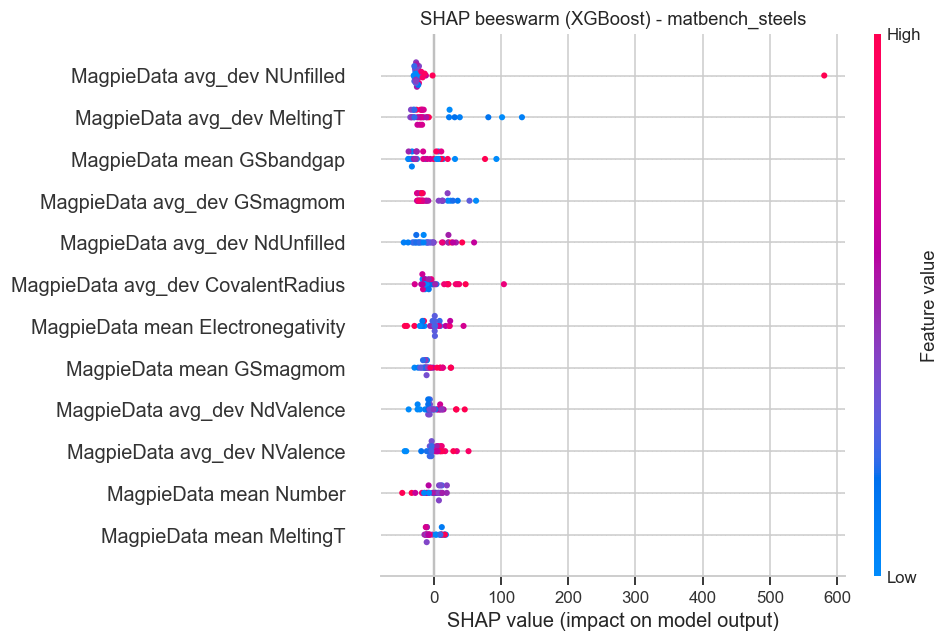

Top-8 features:
MagpieData avg_dev NUnfilled         40.344002
MagpieData avg_dev MeltingT          30.594999
MagpieData mean GSbandgap            23.754000
MagpieData avg_dev GSmagmom          21.323999
MagpieData avg_dev NdUnfilled        20.903000
MagpieData avg_dev CovalentRadius    17.759001
MagpieData mean Electronegativity    13.288000
MagpieData mean GSmagmom             12.612000


In [11]:
import shap
Xs = Xte.sample(min(300, len(Xte)), random_state=RND)
sv = shap.TreeExplainer(xgb).shap_values(Xs)

shap.summary_plot(sv, Xs, max_display=12, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title(f"SHAP beeswarm (XGBoost) - {DATASET}")
plt.tight_layout(); plt.savefig("figures/1c_shap.png", dpi=150, bbox_inches="tight"); plt.show()

imp = pd.Series(np.abs(sv).mean(0), index=Xs.columns).sort_values(ascending=False)
print("Top-8 features:"); print(imp.head(8).round(3).to_string())

## 7. Same features, a classification task

Regression predicts a number; sometimes the useful question is a class. Without a new dataset, we split the same target at its median into high vs low and train a classifier on the same features. Here that reads as "will this composition land in the top or bottom half of the target?" We report accuracy and F1 on the held-out test set.

In [12]:
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

thr = y.median()
ycl = (y > thr).astype(int)                 # 1 = above median, 0 = below
Xtr2, Xte2, ytr2, yte2 = train_test_split(X, ycl, test_size=0.1, random_state=RND, stratify=ycl)
clf = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                    colsample_bytree=0.8, random_state=RND, n_jobs=-1).fit(Xtr2, ytr2)
pc = clf.predict(Xte2)
print(f"threshold (median {DATASETS[DATASET]['label']}): {thr:.4g} {u}")
print(f"high/low classification   accuracy = {accuracy_score(yte2, pc):.3f}   F1 = {f1_score(yte2, pc):.3f}")

threshold (median steel yield strength): 1344 MPa
high/low classification   accuracy = 0.938   F1 = 0.938


## 8. Find your domain

The five datasets span alloys, ceramics, photovoltaics, magnetics, and thermodynamics. Pick the one closest to your own materials, set `DATASET` to its key, and run top to bottom. To go further to your own table, replace `load_one` with a `pd.read_csv` of your data, keep a composition or formula column named `composition` and a numeric `target`, and the rest of the notebook, featurization through SHAP, runs unchanged. That is the same portability 1a promised, shown here across domains rather than told.

## Citations

Datasets are loaded through matminer; the references below come from matminer's own citation metadata (`get_dataset_citations`).

**Tooling**

- Ward, L. et al. "Matminer: An open source toolkit for materials data mining." *Computational Materials Science* **152**, 60-69 (2018). doi:10.1016/j.commatsci.2018.05.018
- Dunn, A., Wang, Q., Ganose, A., Dopp, D., Jain, A. "Benchmarking materials property prediction methods: the Matbench test set and Automatminer reference algorithm." *npj Computational Materials* **6**, 138 (2020). doi:10.1038/s41524-020-00406-3

**Datasets**

- `matbench_steels` - steel yield strength. From the Matbench suite (Dunn et al. 2020, above); original data: Citrine Informatics, "Mechanical properties of some steels," https://citrination.com/datasets/153092/
- `m2ax` - MAX-phase elastic properties. Cover, M. F., Warschkow, O., Bilek, M. M. M., McKenzie, D. R. "A comprehensive survey of M2AX phase elastic properties." *Journal of Physics: Condensed Matter* **21**, 305403 (2009). doi:10.1088/0953-8984/21/30/305403
- `double_perovskites_gap` - double-perovskite band gaps. Pilania, G., Mannodi-Kanakkithodi, A., Uberuaga, B. P., Ramprasad, R., Gubernatis, J. E., Lookman, T. "Machine learning bandgaps of double perovskites." *Scientific Reports* **6**, 19375 (2016). doi:10.1038/srep19375. Data via the Computational Materials Repository, https://cmr.fysik.dtu.dk/
- `heusler_magnetic` - Heusler magnetic properties. Citrine Informatics, "University of Alabama Heusler database," https://citrination.com/datasets/150561/
- `expt_formation_enthalpy` - experimental formation enthalpies. Kim, G., Meschel, S. V., Nash, P., Chen, W. "Experimental formation enthalpies for intermetallic phases and other inorganic compounds." *Scientific Data* **4**, 170162 (2017). doi:10.1038/sdata.2017.162

Released for educational use. Please cite the dataset and tooling references above if you build on this material.